In [100]:
import sys
import os
from pathlib import Path
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
sys.path

['/home/blessyantony/miniconda3/envs/haven/lib/python311.zip',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11/lib-dynload',
 '',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/../../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/../../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/a

In [121]:
import pandas as pd
import os
import numpy as np
import math
import pytaxonkit
import subprocess
import json
import seaborn as sns
import matplotlib.pyplot as plt
from src.utils import utils, evaluation_utils, visualization_utils
from Bio import SeqIO
from sklearn.model_selection import train_test_split
import  subprocess

In [102]:
input_filepath = os.path.join(os.getcwd(), "..","..", "..", "..", "..", "input/data/bvbrc/BVBRC_reference_genome_20260429_proteome_proteins_host_prevalence_gte_onepercent.csv")
input_df = pd.read_csv(input_filepath)

output_dir = os.path.join(os.getcwd(), "tmp")
Path(output_dir).mkdir(parents=True, exist_ok=True)

In [103]:
id_col = "id"
seq_col = "sequence"
label_col = "virus_host_species_tax_name"
input_df["id"] = input_df["proteome_id"] + "_" + input_df["protein"]
input_df

,proteome_id,protein_id,protein,protein_id_name,virus_host_species_tax_id,virus_host_species_tax_name,virus_genus_tax_name,virus_species_tax_name,sequence,is_nucleotide,id
0,HM119410,AEA30058.1,L-protein,AEA30058.1_L-protein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MEEILKKQSIPTGTGLNRPDVKHYDDTIMDVEIPFFHITKCDNFMK...,False,HM119410_L-protein
1,HM119411,AEA30046.1,polyprotein,AEA30046.1_polyprotein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,False,HM119411_polyprotein
2,HM119412,AEA30072.1,nonstructural-protein,AEA30072.1_nonstructural-protein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MSQLLCYAFDLPHITRSATDRSRVYVEYSAHNGSYHTPICRYRGAE...,False,HM119412_nonstructural-protein
3,HM119412,AEA30073.1,nucleocapsid,AEA30073.1_nucleocapsid,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MSFEQLAIELAGHEVDANTIASWVQAFAYQGFDARRVIELLKTRGG...,False,HM119412_nucleocapsid
4,NC_055341,YP_010086120.1,polyprotein,YP_010086120.1_polyprotein,9606,Homo sapiens,Phlebovirus,Phlebovirus echarateense,MKVLLILFHFIVAKASYSLRSWDMRGQNEMCFSNDTPLEGLFYYWM...,False,NC_055341_polyprotein
...,...,...,...,...,...,...,...,...,...,...,...
9635,JQ920006,AFL91895.1,VP4,AFL91895.1_VP4,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MLSYLRKEYATFGGTSDTSKSDQSEATSRSINEKEIKEREKPVKSG...,False,JQ920006_VP4
9636,JQ920007,AFL91896.1,VP7,AFL91896.1_VP7,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MLRLLFLATTAIGQLVMKPVNNNNICVMYPKSRASEVNETVYEPFK...,False,JQ920007_VP7
9637,JQ920008,AFL91897.1,NSP1-1,AFL91897.1_NSP1-1,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MGNSNTNIQVSQQNTHIQASDSKLELHDQKTATLQSTQLLISIGAI...,False,JQ920008_NSP1-1
9638,JQ920008,AFL91898.1,NSP1-2,AFL91898.1_NSP1-2,9031,Gallus gallus,Rotavirus,Rotavirus gammagastroenteritidis,MVISNEKEKFPISGTKDWINSYLINPMISPVVVYEWKDDIADLGMI...,False,JQ920008_NSP1-2


In [9]:
def convert_source_to_fasta(df, column_names, output_dir, output_filename):
    tab_file_path = os.path.join(output_dir, f"{output_filename}.tab")
    with open(tab_file_path, "w+") as f:
        df[column_names].to_csv(f, sep="\t", index=False, header=False)

    fasta_file_path = os.path.join(output_dir, f"{output_filename}.fasta")
    records_count = SeqIO.convert(in_file=tab_file_path, in_format="tab",
                  out_file=fasta_file_path, out_format="fasta")
    print(f"Converted {records_count} records from csv to fasta")
    return fasta_file_path

def convert_target_to_fasta(df, column_name, output_dir, output_filename):
    tab_file_path = os.path.join(output_dir, f"{output_filename}.tab")
    with open(tab_file_path, "w+") as f:
        df[column_name].reset_index().to_csv(f, sep="\t", index=False, header=False)

    fasta_file_path = os.path.join(output_dir, f"{output_filename}.fasta")
    records_count = SeqIO.convert(in_file=tab_file_path, in_format="tab",
                  out_file=fasta_file_path, out_format="fasta")
    print(f"Converted {records_count} records from csv to fasta")
    return fasta_file_path

In [10]:
input_df["virus_host_species_tax_name"].value_counts()

Homo sapiens         4330
Sus scrofa           1984
Gallus gallus        1203
Bos taurus            794
Equus caballus        776
Canis lupus           316
Rattus norvegicus     175
Boa constrictor        62
Name: virus_host_species_tax_name, dtype: int64

In [119]:
def split_dataset_stratified(df, seed, train_proportion, stratify_col=None):
    print(f"Splitting dataset with seed={seed}, train_proportion={train_proportion}, stratify_col={stratify_col}")
    train_df, test_df = train_test_split(df, train_size=train_proportion, random_state=seed, stratify=df[stratify_col])
    print(f"Size of train_dataset = {train_df.shape}")
    print(f"Size of test_dataset = {test_df.shape}")
    return train_df, test_df
    
def split_dataset_based_on_column(df, seed, train_proportion, split_input_col=None, label_col=None):
    print(f"Splitting dataset with train_proportion={train_proportion}, split_input_col={split_input_col}, label_col={label_col}")
    col_values = df[split_input_col].unique().tolist()
    n_col_values = len(col_values)
    print(f"Number of unique values of {split_input_col}={n_col_values}")

    n_train_col_values = int(train_proportion * n_col_values)
    n_test_col_values = n_col_values - n_train_col_values

    print(f"Expected number of train {split_input_col} values = {n_train_col_values}")
    print(f"Expected number of test {split_input_col} values = {n_test_col_values}")

    np.random.seed(seed)
    train_col_values = np.random.choice(col_values, size=n_train_col_values, replace=False)
    test_col_values = list(set(col_values) - set(train_col_values))

    print(f"Number of train {split_input_col} values = {len(train_col_values)}")
    print(f"Number of test {split_input_col} values = {len(test_col_values)}")

    train_df = df[df[split_input_col].isin(train_col_values)]
    test_df = df[df[split_input_col].isin(test_col_values)]

    print(f"Size of train_dataset = {train_df.shape}; number of unique labels = {train_df[label_col].nunique()}")
    print(f"Size of test_dataset = {test_df.shape}; number of unique labels = {test_df[label_col].nunique()}")
    return train_df, test_df

In [117]:
def compute_similarity_scores(input_df, source, target, output_dir):
    source_fasta_file = convert_source_to_fasta(df=input_df[input_df[label_col] == source], column_names=[id_col, seq_col], output_dir=output_dir, output_filename=f"{source.replace(' ', '_')}")
    target_fasta_file = convert_target_to_fasta(df=input_df[input_df[label_col] == target], column_name=seq_col, output_dir=output_dir, output_filename=f"{target.replace(' ', '_')}")
    blastdb_name = f"target-{target.replace(' ', '_')}"
    wd = os.getcwd()
    os.chdir("tmp")
    db_creation_output = subprocess.run(["makeblastdb", "-in", target_fasta_file, "-parse_seqids", "-dbtype", "prot", "-title", blastdb_name ], capture_output=True)
    print(db_creation_output)

    blast_results_filepath = os.path.join(output_dir, f"blast-results-{target.replace(' ', '_')}.txt")
    blast_search_output  = subprocess.run(["blastp",
                            "-db", target_fasta_file,
                            "-query", source_fasta_file,
                            "-out", blast_results_filepath,
                            "-outfmt", "10 qseqid sseqid pident evalue bitscore", # outfmt=10: Comma-separated values
                            "-max_target_seqs", "5",
                            "-num_threads", "5"],
                           capture_output=False)
    os.chdir(wd)
    print(blast_search_output)
    df = pd.read_csv(blast_results_filepath, names=[id_col, "target_seq_id", target, "evalue", "bitscore"])
    df[target] = df[target]/100
    similarity_scores_df = df[[id_col, target]]
    similarity_scores_df.rename(columns={target: "similarity_score"}, inplace=True)
    similarity_scores_df["source_label"] = source
    similarity_scores_df["target_label"] = target
    similarity_scores_df = similarity_scores_df.groupby(["id", "source_label", "target_label"])["similarity_score"].max().reset_index()
    return similarity_scores_df


In [149]:
def compute_similarity_scores_dfs(train_df, test_df, source, target, output_dir, exp_name):
    source_fasta_file = convert_source_to_fasta(df=train_df[train_df[label_col] == source], column_names=[id_col, seq_col], output_dir=output_dir, output_filename=f"{source.replace(' ', '_')}")
    target_fasta_file = convert_target_to_fasta(df=test_df[test_df[label_col] == target], column_name=seq_col, output_dir=output_dir, output_filename=f"{target.replace(' ', '_')}")
    blastdb_name = f"target-{target.replace(' ', '_')}"
    wd = os.getcwd()
    os.chdir("tmp")
    db_creation_output = subprocess.run(["makeblastdb", "-in", target_fasta_file, "-parse_seqids", "-dbtype", "prot", "-title", blastdb_name ], capture_output=True)
    print(db_creation_output)

    blast_results_filepath = os.path.join(output_dir, f"blast-results-{exp_name}-{target.replace(' ', '_')}.txt")
    blast_search_output  = subprocess.run(["blastp",
                            "-db", target_fasta_file,
                            "-query", source_fasta_file,
                            "-out", blast_results_filepath,
                            "-outfmt", "10 qseqid sseqid pident evalue bitscore", # outfmt=10: Comma-separated values
                            "-max_target_seqs", "5",
                            "-num_threads", "5"],
                           capture_output=False)
    os.chdir(wd)
    print(blast_search_output)
    df = pd.read_csv(blast_results_filepath, names=[id_col, "target_seq_id", target, "evalue", "bitscore"])
    df[target] = df[target]/100
    similarity_scores_df = df[[id_col, target]]
    similarity_scores_df.rename(columns={target: "similarity_score"}, inplace=True)
    similarity_scores_df["source_label"] = source
    similarity_scores_df["target_label"] = target
    similarity_scores_df = similarity_scores_df.groupby(["id", "source_label", "target_label"])["similarity_score"].max().reset_index()
    return similarity_scores_df

In [84]:
def analyze_sequence_similarity(similarity_df, labels):
    n_labels = len(labels)
    plt.rcParams['xtick.labelsize'] = 18
    plt.rcParams['ytick.labelsize'] = 18
    plt.rcParams.update({'font.size': 18})
    fig, axs = plt.subplots(n_labels, n_labels, figsize=(42, 42), sharex=False, sharey=False)
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True)
    
    for i, source_label in enumerate(labels):
        for j, target_label in enumerate(labels):
            ax = axs[i][j]
                
            if i == j:
                sns.histplot(data=similarity_df[(similarity_df["source_label"] == source_label) & (similarity_df["target_label"] == target_label)], x="similarity_score", 
                            ax=ax, bins=9)
                ax.set_xlim(0.0, 1.1)
            else:
                sns.kdeplot(data=similarity_df[(similarity_df["source_label"] == source_label) & (similarity_df["target_label"] == target_label)], x="similarity_score", 
                            ax=ax,
                            linewidth=1.5)
            #ax.set_xlabel(f"Similarity w/ {y_train_class}", size=0, labelpad=0)
            ax.set_ylabel(f"{source_label}\n\nDensity", size=20)
            ax.set_title(f"Similarity w/\n{target_label}", size=20)
            ax.set_xlim(0.0, 1)
            #plt.setp(ax.get_legend().get_texts(), fontsize=20)
    plt.tight_layout()
    plt.show()
            #ax.get_legend().set_title("")

In [129]:
def analyze_sequence_similarity_splits(similarity_df, labels):
    n_labels = len(labels)
    plt.rcParams['xtick.labelsize'] = 18
    plt.rcParams['ytick.labelsize'] = 18
    plt.rcParams.update({'font.size': 18})
    fig, axs = plt.subplots(n_labels, n_labels, figsize=(42, 42), sharex=False, sharey=False)
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=similarity_df["split_type"].nunique())
    
    for i, source_label in enumerate(labels):
        for j, target_label in enumerate(labels):
            ax = axs[i][j]
                
            sns.kdeplot(data=similarity_df[(similarity_df["source_label"] == source_label) & (similarity_df["target_label"] == target_label)],
                        x="similarity_score", 
                        hue="split_type", 
                        palette=color_palette,
                        ax=ax,
                        linewidth=1.5)
            #ax.set_xlabel(f"Similarity w/ {y_train_class}", size=0, labelpad=0)
            ax.set_ylabel(f"{source_label}\n\nDensity", size=20)
            ax.set_title(f"Similarity w/\n{target_label}", size=20)
            ax.set_xlim(0.0, 1)
            plt.setp(ax.get_legend().get_texts(), fontsize=20)
            ax.get_legend().set_title("")
            #plt.setp(ax.get_legend().get_texts(), fontsize=20)
    plt.tight_layout()
    plt.show()

## Similarity between all pairs of classes in the full dataset

In [44]:
labels = list(input_df["virus_host_species_tax_name"].unique())
labels

['Homo sapiens',
 'Gallus gallus',
 'Bos taurus',
 'Equus caballus',
 'Sus scrofa',
 'Rattus norvegicus',
 'Canis lupus',
 'Boa constrictor']

In [45]:
similarity_scores_dfs = []
for source in labels:
    for target in labels:
        similarity_scores_dfs.append(compute_similarity_scores(input_df, source, target, output_dir))

Converted 4330 records from csv to fasta
Converted 4330 records from csv to fasta
CompletedProcess(args=['makeblastdb', '-in', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Homo_sapiens.fasta', '-parse_seqids', '-dbtype', 'prot', '-title', 'target-Homo_sapiens'], returncode=0, stdout=b'\n\nBuilding a new DB, current time: 09/15/2026 17:08:05\nNew DB name:   /home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Homo_sapiens.fasta\nNew DB title:  target-Homo_sapiens\nSequence type: Protein\nKeep MBits: T\nMaximum file size: 3000000000B\nAdding sequences from FASTA; added 4330 sequences in 0.0422561 seconds.\n\n\n', stderr=b'')
CompletedProcess(args=['blastp', '-db', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Homo_sapiens.fasta', '-query', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Homo_sapiens.fasta', '-out', '/home/blessyantony/dev/git/HAVE

/tmp/ipykernel_310126/1085037080.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df.rename(columns={target: "similarity_score"}, inplace=True)
/tmp/ipykernel_310126/1085037080.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df["source_label"] = source
/tmp/ipykernel_310126/1085037080.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

CompletedProcess(args=['blastp', '-db', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Gallus_gallus.fasta', '-query', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Homo_sapiens.fasta', '-out', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/blast-results-Gallus_gallus.txt', '-outfmt', '10 qseqid sseqid pident evalue bitscore', '-max_target_seqs', '5', '-num_threads', '5'], returncode=0)
Converted 4330 records from csv to fasta
Converted 794 records from csv to fasta
CompletedProcess(args=['makeblastdb', '-in', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Bos_taurus.fasta', '-parse_seqids', '-dbtype', 'prot', '-title', 'target-Bos_taurus'], returncode=0, stdout=b'\n\nBuilding a new DB, current time: 09/15/2026 17:08:58\nNew DB name:   /home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Bos_taurus.fasta\nNew 

/tmp/ipykernel_310126/1085037080.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df.rename(columns={target: "similarity_score"}, inplace=True)
/tmp/ipykernel_310126/1085037080.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df["source_label"] = source
/tmp/ipykernel_310126/1085037080.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

CompletedProcess(args=['blastp', '-db', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Bos_taurus.fasta', '-query', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Homo_sapiens.fasta', '-out', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/blast-results-Bos_taurus.txt', '-outfmt', '10 qseqid sseqid pident evalue bitscore', '-max_target_seqs', '5', '-num_threads', '5'], returncode=0)
Converted 4330 records from csv to fasta
Converted 776 records from csv to fasta
CompletedProcess(args=['makeblastdb', '-in', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Equus_caballus.fasta', '-parse_seqids', '-dbtype', 'prot', '-title', 'target-Equus_caballus'], returncode=0, stdout=b'\n\nBuilding a new DB, current time: 09/15/2026 17:09:14\nNew DB name:   /home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Equus_caballus.fasta

...

/tmp/ipykernel_310126/1085037080.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df.rename(columns={target: "similarity_score"}, inplace=True)
/tmp/ipykernel_310126/1085037080.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df["source_label"] = source
/tmp/ipykernel_310126/1085037080.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

CompletedProcess(args=['blastp', '-db', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Canis_lupus.fasta', '-query', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Boa_constrictor.fasta', '-out', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/blast-results-Canis_lupus.txt', '-outfmt', '10 qseqid sseqid pident evalue bitscore', '-max_target_seqs', '5', '-num_threads', '5'], returncode=0)
Converted 62 records from csv to fasta
Converted 62 records from csv to fasta
CompletedProcess(args=['makeblastdb', '-in', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Boa_constrictor.fasta', '-parse_seqids', '-dbtype', 'prot', '-title', 'target-Boa_constrictor'], returncode=0, stdout=b'\n\nBuilding a new DB, current time: 09/15/2026 17:13:32\nNew DB name:   /home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Boa_constrictor.

/tmp/ipykernel_310126/1085037080.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df.rename(columns={target: "similarity_score"}, inplace=True)
/tmp/ipykernel_310126/1085037080.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df["source_label"] = source
/tmp/ipykernel_310126/1085037080.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

CompletedProcess(args=['blastp', '-db', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Boa_constrictor.fasta', '-query', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Boa_constrictor.fasta', '-out', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/blast-results-Boa_constrictor.txt', '-outfmt', '10 qseqid sseqid pident evalue bitscore', '-max_target_seqs', '5', '-num_threads', '5'], returncode=0)


/tmp/ipykernel_310126/1085037080.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df.rename(columns={target: "similarity_score"}, inplace=True)
/tmp/ipykernel_310126/1085037080.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df["source_label"] = source
/tmp/ipykernel_310126/1085037080.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

In [47]:
all_similarity_scores_df = pd.concat(similarity_scores_dfs)
all_similarity_scores_df

,id,source_label,target_label,similarity_score
0,0,Homo sapiens,Homo sapiens,1.0
1,1,Homo sapiens,Homo sapiens,1.0
2,2,Homo sapiens,Homo sapiens,1.0
3,3,Homo sapiens,Homo sapiens,1.0
4,4,Homo sapiens,Homo sapiens,1.0
...,...,...,...,...
57,6581,Boa constrictor,Boa constrictor,1.0
58,6929,Boa constrictor,Boa constrictor,1.0
59,6930,Boa constrictor,Boa constrictor,1.0
60,6931,Boa constrictor,Boa constrictor,1.0


In [83]:
label_mapping = {
    "Homo sapiens": "Human",
    "Gallus gallus": "Chicken",
    "Sus scrofa": "Pig",
    "Bos taurus": "Domestic cattle",
    "Rattus norvegicus": "Norway rat",
    "Equus caballus": "Horse",
    "Canis lupus": "Wolf",
    "Boa constrictor": "Boa",
}
all_similarity_scores_df = all_similarity_scores_df.replace({"source_label": label_mapping, "target_label": label_mapping})
mapped_labels = list(label_mapping.values())

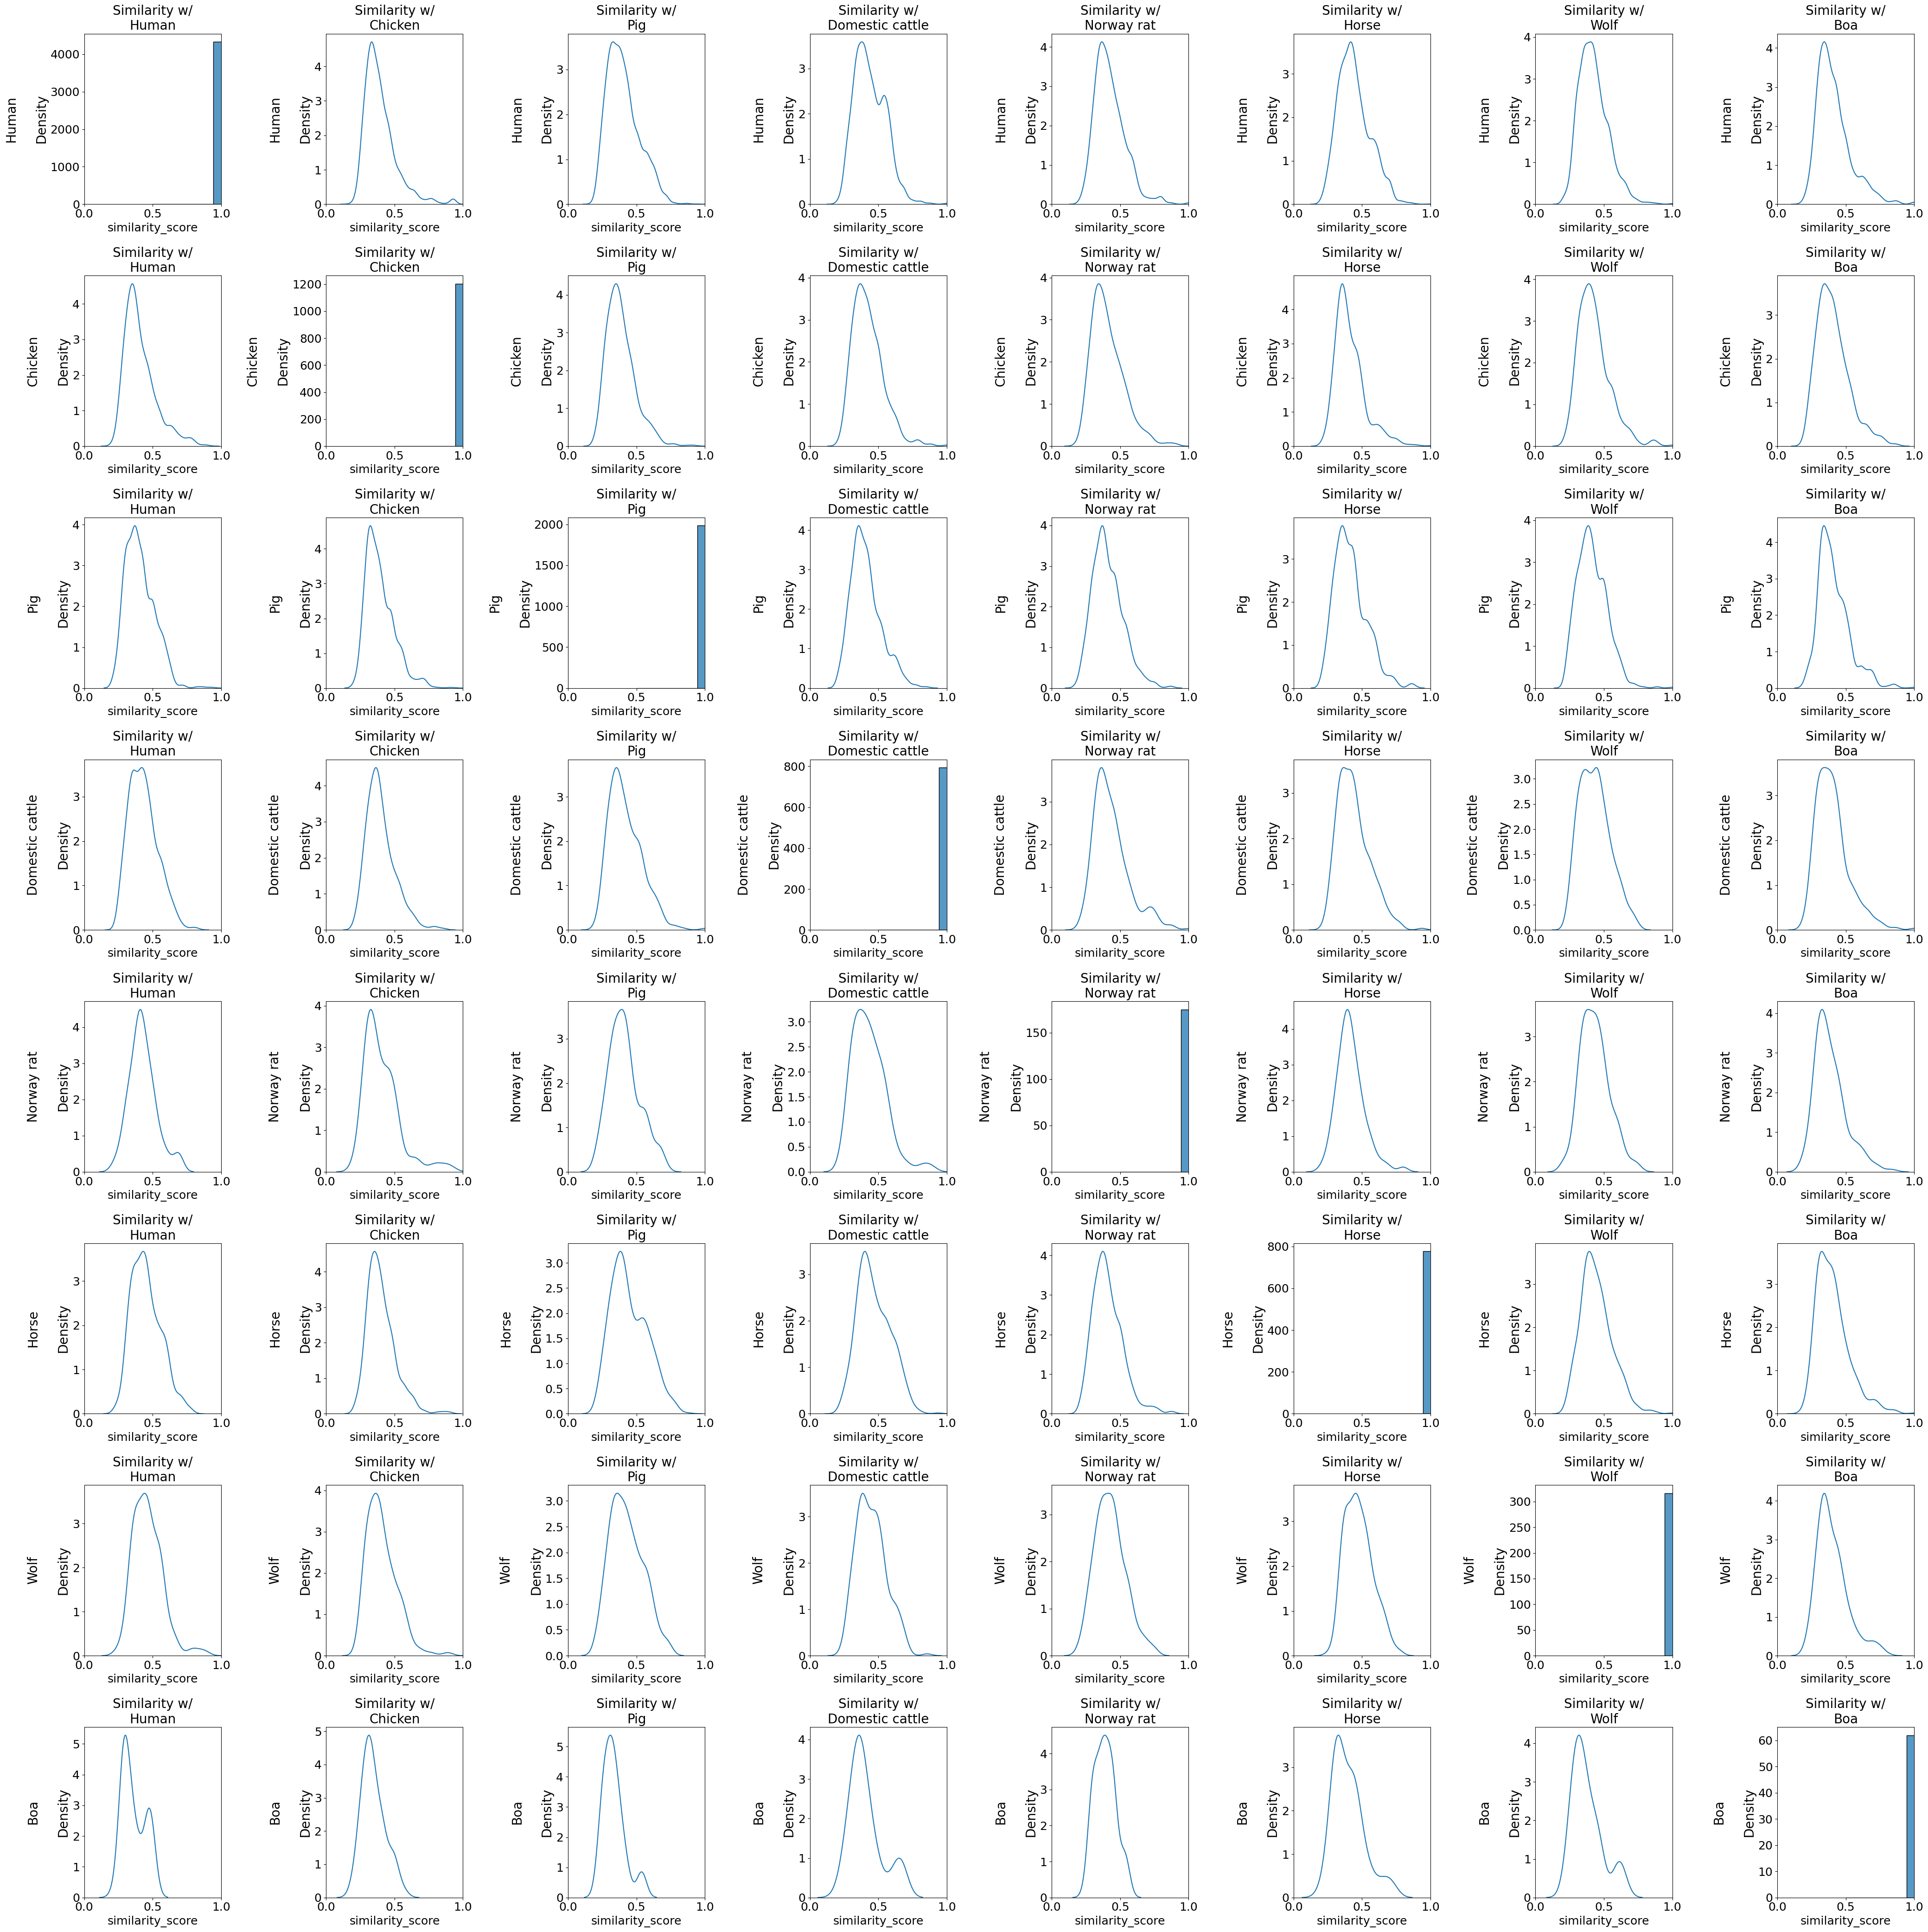

In [85]:
analyze_sequence_similarity(all_similarity_scores_df, mapped_labels)

## Similarity between all pairs of classes in random split dataset

In [122]:
train_df, test_df = split_dataset_stratified(input_df, 12612648, .8, stratify_col=label_col)

Splitting dataset with seed=12612648, train_proportion=0.8, stratify_col=virus_host_species_tax_name
Size of train_dataset = (7712, 11)
Size of test_dataset = (1928, 11)


In [150]:
similarity_scores_dfs = []
for source in labels:
    for target in labels:
        similarity_scores_dfs.append(compute_similarity_scores_dfs(train_df, test_df, source, target, output_dir, exp_name="random"))

Converted 3987 records from csv to fasta
Converted 343 records from csv to fasta
CompletedProcess(args=['makeblastdb', '-in', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Homo_sapiens.fasta', '-parse_seqids', '-dbtype', 'prot', '-title', 'target-Homo_sapiens'], returncode=0, stdout=b'\n\nBuilding a new DB, current time: 09/15/2026 19:26:32\nNew DB name:   /home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Homo_sapiens.fasta\nNew DB title:  target-Homo_sapiens\nSequence type: Protein\nDeleted existing Protein BLAST database named /home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Homo_sapiens.fasta\nKeep MBits: T\nMaximum file size: 3000000000B\nAdding sequences from FASTA; added 343 sequences in 0.00467896 seconds.\n\n\n', stderr=b'')
CompletedProcess(args=['blastp', '-db', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Homo_sapiens.fasta', '-query

/tmp/ipykernel_310126/2451343388.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df.rename(columns={target: "similarity_score"}, inplace=True)
/tmp/ipykernel_310126/2451343388.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df["source_label"] = source
/tmp/ipykernel_310126/2451343388.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

CompletedProcess(args=['blastp', '-db', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Gallus_gallus.fasta', '-query', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Homo_sapiens.fasta', '-out', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/blast-results-random-Gallus_gallus.txt', '-outfmt', '10 qseqid sseqid pident evalue bitscore', '-max_target_seqs', '5', '-num_threads', '5'], returncode=0)
Converted 3987 records from csv to fasta
Converted 99 records from csv to fasta
CompletedProcess(args=['makeblastdb', '-in', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Bos_taurus.fasta', '-parse_seqids', '-dbtype', 'prot', '-title', 'target-Bos_taurus'], returncode=0, stdout=b'\n\nBuilding a new DB, current time: 09/15/2026 19:26:44\nNew DB name:   /home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Bos_taurus.fasta

/tmp/ipykernel_310126/2451343388.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df.rename(columns={target: "similarity_score"}, inplace=True)
/tmp/ipykernel_310126/2451343388.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df["source_label"] = source
/tmp/ipykernel_310126/2451343388.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

CompletedProcess(args=['blastp', '-db', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Bos_taurus.fasta', '-query', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Homo_sapiens.fasta', '-out', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/blast-results-random-Bos_taurus.txt', '-outfmt', '10 qseqid sseqid pident evalue bitscore', '-max_target_seqs', '5', '-num_threads', '5'], returncode=0)
Converted 3987 records from csv to fasta
Converted 5 records from csv to fasta
CompletedProcess(args=['makeblastdb', '-in', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Equus_caballus.fasta', '-parse_seqids', '-dbtype', 'prot', '-title', 'target-Equus_caballus'], returncode=0, stdout=b'\n\nBuilding a new DB, current time: 09/15/2026 19:26:51\nNew DB name:   /home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Equus_caballus.

...

/tmp/ipykernel_310126/2451343388.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df.rename(columns={target: "similarity_score"}, inplace=True)
/tmp/ipykernel_310126/2451343388.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df["source_label"] = source
/tmp/ipykernel_310126/2451343388.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

CompletedProcess(args=['blastp', '-db', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Canis_lupus.fasta', '-query', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Boa_constrictor.fasta', '-out', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/blast-results-random-Canis_lupus.txt', '-outfmt', '10 qseqid sseqid pident evalue bitscore', '-max_target_seqs', '5', '-num_threads', '5'], returncode=0)
Converted 30 records from csv to fasta
Converted 32 records from csv to fasta
CompletedProcess(args=['makeblastdb', '-in', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Boa_constrictor.fasta', '-parse_seqids', '-dbtype', 'prot', '-title', 'target-Boa_constrictor'], returncode=0, stdout=b'\n\nBuilding a new DB, current time: 09/15/2026 19:28:30\nNew DB name:   /home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Boa_const

/tmp/ipykernel_310126/2451343388.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df.rename(columns={target: "similarity_score"}, inplace=True)
/tmp/ipykernel_310126/2451343388.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df["source_label"] = source
/tmp/ipykernel_310126/2451343388.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

CompletedProcess(args=['blastp', '-db', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Boa_constrictor.fasta', '-query', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Boa_constrictor.fasta', '-out', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/blast-results-random-Boa_constrictor.txt', '-outfmt', '10 qseqid sseqid pident evalue bitscore', '-max_target_seqs', '5', '-num_threads', '5'], returncode=0)


/tmp/ipykernel_310126/2451343388.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df.rename(columns={target: "similarity_score"}, inplace=True)
/tmp/ipykernel_310126/2451343388.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df["source_label"] = source
/tmp/ipykernel_310126/2451343388.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

In [151]:
all_similarity_scores_df_random_split = pd.concat(similarity_scores_dfs)
all_similarity_scores_df_random_split["split_type"] = "random"

In [152]:
all_similarity_scores_df_random_split = all_similarity_scores_df_random_split.replace({"source_label": label_mapping, "target_label": label_mapping})
mapped_labels = list(label_mapping.values())

## Similarity between all pairs of classes in virus-genus split dataset

In [127]:
train_df, test_df = split_dataset_based_on_column(input_df, 12612648, .8, split_input_col="virus_genus_tax_name", label_col=label_col)

Splitting dataset with train_proportion=0.8, split_input_col=virus_genus_tax_name, label_col=virus_host_species_tax_name
Number of unique values of virus_genus_tax_name=141
Expected number of train virus_genus_tax_name values = 112
Expected number of test virus_genus_tax_name values = 29
Number of train virus_genus_tax_name values = 112
Number of test virus_genus_tax_name values = 29
Size of train_dataset = (7238, 11); number of unique labels = 8
Size of test_dataset = (2402, 11); number of unique labels = 8


In [130]:
similarity_scores_dfs = []
for source in labels:
    for target in labels:
        similarity_scores_dfs.append(compute_similarity_scores_dfs(train_df, test_df, source, target, output_dir, exp_name="vg"))

Converted 3987 records from csv to fasta
Converted 343 records from csv to fasta
CompletedProcess(args=['makeblastdb', '-in', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Homo_sapiens.fasta', '-parse_seqids', '-dbtype', 'prot', '-title', 'target-Homo_sapiens'], returncode=0, stdout=b'\n\nBuilding a new DB, current time: 09/15/2026 18:49:08\nNew DB name:   /home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Homo_sapiens.fasta\nNew DB title:  target-Homo_sapiens\nSequence type: Protein\nDeleted existing Protein BLAST database named /home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Homo_sapiens.fasta\nKeep MBits: T\nMaximum file size: 3000000000B\nAdding sequences from FASTA; added 343 sequences in 0.00435185 seconds.\n\n\n', stderr=b'')
CompletedProcess(args=['blastp', '-db', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Homo_sapiens.fasta', '-query

/tmp/ipykernel_310126/4117336382.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df.rename(columns={target: "similarity_score"}, inplace=True)
/tmp/ipykernel_310126/4117336382.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df["source_label"] = source
/tmp/ipykernel_310126/4117336382.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

CompletedProcess(args=['blastp', '-db', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Gallus_gallus.fasta', '-query', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Homo_sapiens.fasta', '-out', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/blast-results-Gallus_gallus.txt', '-outfmt', '10 qseqid sseqid pident evalue bitscore', '-max_target_seqs', '5', '-num_threads', '5'], returncode=0)
Converted 3987 records from csv to fasta
Converted 99 records from csv to fasta
CompletedProcess(args=['makeblastdb', '-in', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Bos_taurus.fasta', '-parse_seqids', '-dbtype', 'prot', '-title', 'target-Bos_taurus'], returncode=0, stdout=b'\n\nBuilding a new DB, current time: 09/15/2026 18:49:20\nNew DB name:   /home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Bos_taurus.fasta\nNew D

/tmp/ipykernel_310126/4117336382.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df.rename(columns={target: "similarity_score"}, inplace=True)
/tmp/ipykernel_310126/4117336382.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df["source_label"] = source
/tmp/ipykernel_310126/4117336382.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

CompletedProcess(args=['blastp', '-db', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Bos_taurus.fasta', '-query', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Homo_sapiens.fasta', '-out', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/blast-results-Bos_taurus.txt', '-outfmt', '10 qseqid sseqid pident evalue bitscore', '-max_target_seqs', '5', '-num_threads', '5'], returncode=0)
Converted 3987 records from csv to fasta
Converted 5 records from csv to fasta
CompletedProcess(args=['makeblastdb', '-in', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Equus_caballus.fasta', '-parse_seqids', '-dbtype', 'prot', '-title', 'target-Equus_caballus'], returncode=0, stdout=b'\n\nBuilding a new DB, current time: 09/15/2026 18:49:26\nNew DB name:   /home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Equus_caballus.fasta\n

...

/tmp/ipykernel_310126/4117336382.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df.rename(columns={target: "similarity_score"}, inplace=True)
/tmp/ipykernel_310126/4117336382.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df["source_label"] = source
/tmp/ipykernel_310126/4117336382.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

CompletedProcess(args=['blastp', '-db', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Canis_lupus.fasta', '-query', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Boa_constrictor.fasta', '-out', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/blast-results-Canis_lupus.txt', '-outfmt', '10 qseqid sseqid pident evalue bitscore', '-max_target_seqs', '5', '-num_threads', '5'], returncode=0)
Converted 30 records from csv to fasta
Converted 32 records from csv to fasta
CompletedProcess(args=['makeblastdb', '-in', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Boa_constrictor.fasta', '-parse_seqids', '-dbtype', 'prot', '-title', 'target-Boa_constrictor'], returncode=0, stdout=b'\n\nBuilding a new DB, current time: 09/15/2026 18:51:05\nNew DB name:   /home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Boa_constrictor.

/tmp/ipykernel_310126/4117336382.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df.rename(columns={target: "similarity_score"}, inplace=True)
/tmp/ipykernel_310126/4117336382.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df["source_label"] = source
/tmp/ipykernel_310126/4117336382.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

CompletedProcess(args=['blastp', '-db', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Boa_constrictor.fasta', '-query', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/Boa_constrictor.fasta', '-out', '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/datasets/analysis/bvbrc/tmp/blast-results-Boa_constrictor.txt', '-outfmt', '10 qseqid sseqid pident evalue bitscore', '-max_target_seqs', '5', '-num_threads', '5'], returncode=0)


/tmp/ipykernel_310126/4117336382.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df.rename(columns={target: "similarity_score"}, inplace=True)
/tmp/ipykernel_310126/4117336382.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  similarity_scores_df["source_label"] = source
/tmp/ipykernel_310126/4117336382.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

In [131]:
all_similarity_scores_df_genus_split = pd.concat(similarity_scores_dfs)
all_similarity_scores_df_genus_split["split_type"] = "virus_genus"

In [132]:
all_similarity_scores_df_genus_split = all_similarity_scores_df_genus_split.replace({"source_label": label_mapping, "target_label": label_mapping})
mapped_labels = list(label_mapping.values())

/tmp/ipykernel_310126/3751464383.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=similarity_df[(similarity_df["source_label"] == source_label) & (similarity_df["target_label"] == target_label)],
/tmp/ipykernel_310126/3751464383.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=similarity_df[(similarity_df["source_label"] == source_label) & (similarity_df["target_label"] == target_label)],
/tmp/ipykernel_310126/3751464383.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=similarity_df[(similarity_df["source_label"] == source_label) & (similarity_df["target_label"] == target_label)],
/tmp/ipykernel_310126/3751464383.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to

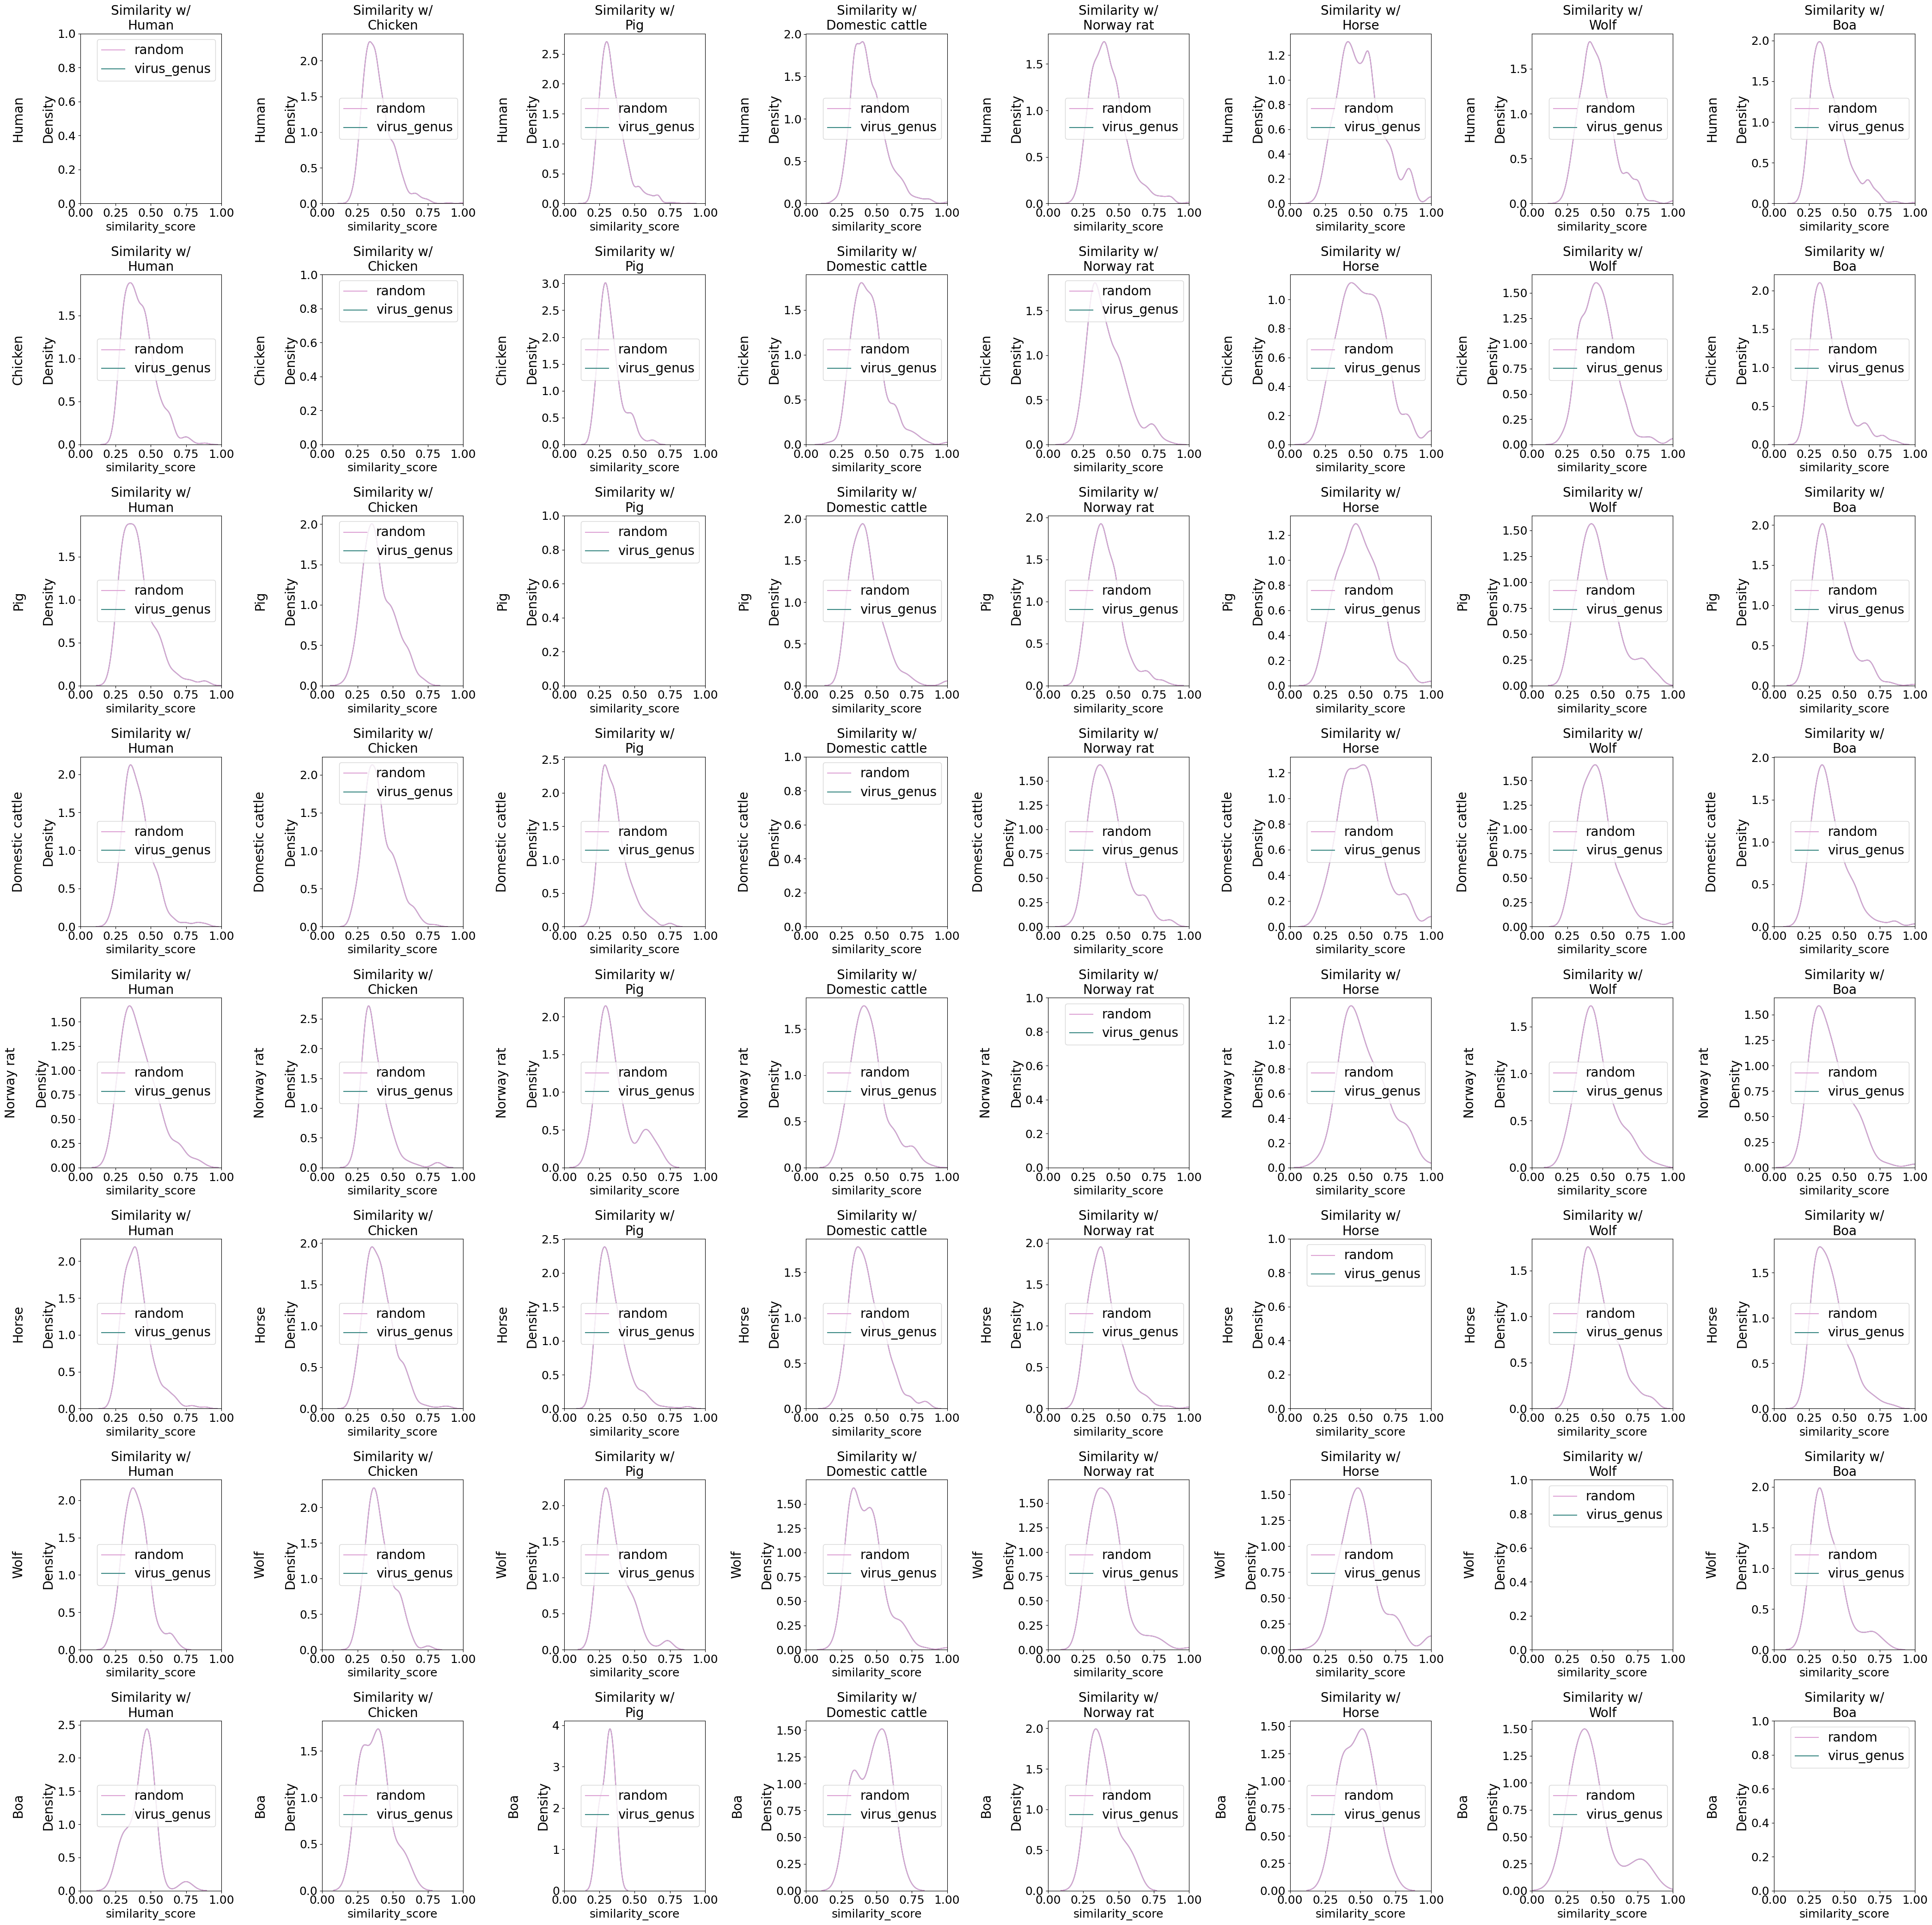

In [153]:
analyze_sequence_similarity_splits(pd.concat([all_similarity_scores_df_random_split, all_similarity_scores_df_genus_split]), mapped_labels)

In [138]:
similarity_scores_dfs[0]

,id,source_label,target_label,similarity_score
0,2649,Homo sapiens,Homo sapiens,1.0
1,2650,Homo sapiens,Homo sapiens,1.0
2,2651,Homo sapiens,Homo sapiens,1.0
3,2652,Homo sapiens,Homo sapiens,1.0
4,2653,Homo sapiens,Homo sapiens,1.0
...,...,...,...,...
338,9548,Homo sapiens,Homo sapiens,1.0
339,9549,Homo sapiens,Homo sapiens,1.0
340,9550,Homo sapiens,Homo sapiens,1.0
341,9551,Homo sapiens,Homo sapiens,1.0


In [147]:
test_df.loc[2649, :]

proteome_id                                                             AJ620205
protein_id                                                            CAF05783.1
protein                                                               E6-protein
protein_id_name                                            CAF05783.1_E6-protein
virus_host_species_tax_id                                                   9606
virus_host_species_tax_name                                         Homo sapiens
virus_genus_tax_name                                         Alphapapillomavirus
virus_species_tax_name                                     Alphapapillomavirus 8
sequence                       MTARSCSQNARTIFELCDECNITLPTLQIGCIFCKKWLLTTEVLSF...
is_nucleotide                                                              False
id                                                           AJ620205_E6-protein
Name: 2649, dtype: object

In [141]:
same_sequence = test_df.loc[2649, :]["sequence"]
same_sequence

'MTARSCSQNARTIFELCDECNITLPTLQIGCIFCKKWLLTTEVLSFAFRDLKVVWRDGYPFAACLACLQFHGKISQYRHFDYAAYADTVEEETKQTVFDLCIRCCKCHKPLSPVEKVQHIVQKAQFFKIHSVWKGYCLHCWKSCMEKSRRSETMC'

In [143]:
train_df[train_df["sequence"] == same_sequence]

,proteome_id,protein_id,protein,protein_id_name,virus_host_species_tax_id,virus_host_species_tax_name,virus_genus_tax_name,virus_species_tax_name,sequence,is_nucleotide,id
